In [316]:
import qiskit.circuit
from qiskit.circuit import QuantumCircuit, QuantumRegister, AncillaRegister, ClassicalRegister
from qiskit.circuit.library import DiagonalGate, QFTGate
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Operator, Statevector
from qiskit import transpile

from IPython.display import display, Image
import matplotlib.pyplot as plt
import numpy as np

# Eigenvalue preparation
We construct a function `eigenprep(U,d,t,K)` with the following inputs:
- $U$: a $2^n \times 2^n$ diagonal unitary matrix $U$ with $distinct$ eigenvalues $U |x \rangle = e^{2\pi i \varphi(x)}|x \rangle$, where $2^d\varphi(x) \in \mathbb{Z}$ and there exists precisely one eigenvector $|x'\rangle$ with $\varphi(x')=t$.
- $d$: integer such that $2^d\varphi(x) \in \mathbb{Z}$ for all $x$.
- $t$: Desired phase of ouput basis vector.
- $K$: Number of iterations of Grover Search used to find $|x' \rangle$. Defaults to the value maximizing the probability that the search is successful.
  
`eigenprep(U,d,t,K)` outputs a Quantum Circuit that prepares the desired state $|x'\rangle$ satisfying $\varphi(x')=t$ using Grover Search.

The circuit is standard Grover Search, where the Oracle tags the desired state $|x \rangle$ using Quantum Phase Estimation. Therefore we build our circuit in 3 stages:

- Quantum Phase Estimation circuit with $d$ bits of precision.
- Oracle circuit
- Diffuser circuit
- Grover circuit (compose Oracle and Diffuser $K$ times)

## Quantum Phase Estimation Circuit

We begin by constructing a circuit for Quantum Phase estimation. This takes $U$ as above in the form of its diagonal $[U| 0 \rangle, U|2\rangle, \dots U|2^n\rangle]$ and yields a Quantum circuit that transforms a state 

$$|\psi \rangle = \sum_x \alpha_x |x\rangle \otimes |0\rangle$$

into the state

$$\sum_x \alpha_{x} |x\rangle \otimes |\varphi(x) \rangle $$

This uses Controlled $U^{2^i}$ gates for $i=0,\dots,d$, as well as the inverse Quantum Fourier Transform gate.
Note that if we didn't have $t$ such that $2^{d} t \in \mathbb{Z}$, we would have $|\widetilde{\varphi}(x) \rangle$ in place of $|\varphi(x) \rangle$, which would be an estimation of $\varphi(x)$ to $d$ bits of precision. 

In [ ]:
def QPE(unitary, precision: int):
    ''' Quantum Phase Estimation, given diagonal unitary matrix'''
    n = int(np.log2(len(unitary)))
    quantum_register = QuantumRegister(size=n, name="q")  # n qubits input state
    ancilla_register = AncillaRegister(
        size=precision, name="a"
    )  # d qubits for QPE: Ancilla bits which we need to reset to |0> afterwards

    QPE_circ = QuantumCircuit(quantum_register, ancilla_register, name="QPE")
    QPE_circ.h(ancilla_register) 

    unitary_gate = DiagonalGate(unitary)  # Build Unitary gate

    for k in range(precision):
        unitary_power = unitary_gate.power(1 << k)
        unitary_power.label = rf"$U^{{2^{k}}}$"
        controlled_unitary_gate = unitary_power.control()  # Control gate for U^{2^k}
        QPE_circ.append(
            controlled_unitary_gate, [ancilla_register[k]] + list(quantum_register)
        )  # Control using kth ancilla, target all quantumregister

    QPE_circ.append(
        QFTGate(precision).inverse(), ancilla_register
    )  # Inverse Fourier transform on ancillas
    return QPE_circ

### Example Quantum Phase Estimation Circuit

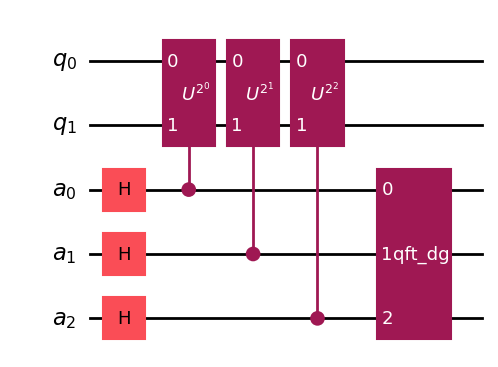

In [182]:
qc = QPE(np.array([1, 1j, -1, -1j]), 3)
display(qc.draw("mpl"))

## Oracle Circuit

Now we construct our oracle ciruit, which should send 

$$ \sum_x \alpha_x |x\rangle \otimes |0\rangle \mapsto  \sum_x (-1)^{f(x)}\alpha_x |x\rangle \otimes |0\rangle,$$

where $f(x)=1$ iff $\varphi(x)=t$, and is $0$ otherwise. We achieve this in 3 steps:
- Apply QPE circuit to send $|x\rangle \otimes |0\rangle$ to $|x\rangle \otimes | \varphi(x) \rangle$.
- Tag state $|x\rangle$ by applying a multi-controlled Z (MCZ) gate, yielding $(-1)^{f(x)} |x\rangle \otimes |\varphi(x) \rangle$, where $f(x)=1$ iff $\varphi(x)=t$, and equals 0 otherwise.
- Apply inverse QPE circuit to yield $|x\rangle \otimes | 0 \rangle$.

In [ ]:
def oracle(unitary, precision: int, target: float):
    '''Oracle to mark basis state with target phase'''
    n = int(np.log2(len(unitary)))  # number of qubits needed

    quantum_register = QuantumRegister(size=n, name="a")
    ancilla_register = AncillaRegister(size=precision, name="q")
    oracle_circuit = QuantumCircuit(quantum_register, ancilla_register, name="oracle")

    QPEGate = QPE(unitary, precision).to_gate()
    oracle_circuit.compose(QPEGate, inplace=True)

    # Desired state will be all 1's: repesent t in binary little-endian
    target_string = ("{0:0" + str(precision) + "b}").format(
        int(target * 2**precision)
    )[::-1]

    # Flip so that t*2**d sent to all 1s
    for k in range(len(target_string)):
        if target_string[k] == "0":
            oracle_circuit.x(ancilla_register[k])

    # Negate desired state only
    oracle_circuit.mcp(np.pi, ancilla_register[0 : precision - 1], ancilla_register[-1])

    # Now undo bit flips
    for k in range(len(target_string)):
        if target_string[k] == "0":
            oracle_circuit.x(ancilla_register[k])

    oracle_circuit.compose(QPEGate.inverse(), inplace=True)  # uncompute

    return oracle_circuit

### Example Oracle Circuit

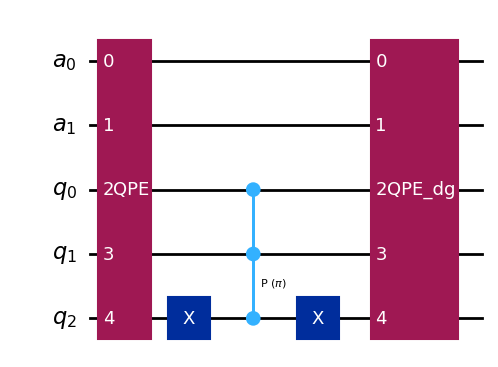

In [184]:
qc = oracle(np.array([1, 1j, -1, -1j]), 3, 3 / 8)
display(qc.draw("mpl"))

Now we apply Grover's algorithm. First we construct the diffuser circuit, which applies the operator $\text{diag}(-1,1,\dots,1)$ between Hadamard gates.

In [295]:
def diffuser_circuit(qubits: int):
    '''Diffuser circuit for Grover search'''
    quantum_register = QuantumRegister(
        size=qubits, name="q"
    )  # Vector to be rotated closer and closer to desired |x>

    diffuser_circuit = QuantumCircuit(
        quantum_register, name="diffuser"
    )  # Does not act on ancilla bits

    diffuser_circuit.h(quantum_register)  # Hadamard all

    # Apply -2 |0><0| + I i.e. reflect |0> around |0> perp
    diffuser_circuit.x(quantum_register)  #bit flip all bits
    diffuser_circuit.mcp(
        np.pi, quantum_register[1:qubits], quantum_register[0]
    )
    diffuser_circuit.x(quantum_register)
    diffuser_circuit.h(quantum_register)  

    return diffuser_circuit

## Grover Search Circuit

Combining the Oracle with the Diffuser yields the Grover Operator, $G$. Now we just have to apply Hadamard gates to our QuantumRegister and then compose with our $G$ circuit $K$ times.

Next, we define our function `eigenprep(U,d,t,K)`:

In [296]:
def eigenvalue_preparation(unitary, precision: int, target: float, iterations=None):
    ''' Returns QuantumCircuit that runs Grover search with specified number of iterations to identify 
    which basis state of of diagonal Unitary matrix has the specified target phase'''
    target = target % 1
    n = int(np.log2(len(unitary)))  # Number of non-ancilla qubits needed

    quantum_register = QuantumRegister(size=n, name="q")
    ancilla_register = AncillaRegister(
        size=precision, name="a"
    )  # qubits for Oracle workspace

    EV_Prep = QuantumCircuit(quantum_register, ancilla_register, name="EVP")

    oracle_gate = oracle(unitary, precision, target).to_gate()  # turn oracle into gate
    diffuser_gate = diffuser_circuit(n).to_gate(
        label="diffuser"
    )  # turn diffuser into gate

    EV_Prep.h(quantum_register)  # First must prepare |+> state

    if iterations is None:
        iterations = int(
            np.rint(np.pi / (4 * np.arcsin(1 / np.sqrt(1 << n))) - 1 / 2)
        )  # number of iterations

    for _ in range(iterations):
        EV_Prep.barrier()
        EV_Prep.compose(oracle_gate, inplace=True)
        EV_Prep.barrier()
        EV_Prep.compose(diffuser_gate, quantum_register, inplace=True)
    return EV_Prep

For example, when there are $8$ states to search through, $K=2$ iterations of Grover search is optimal, yielding the following circuit:

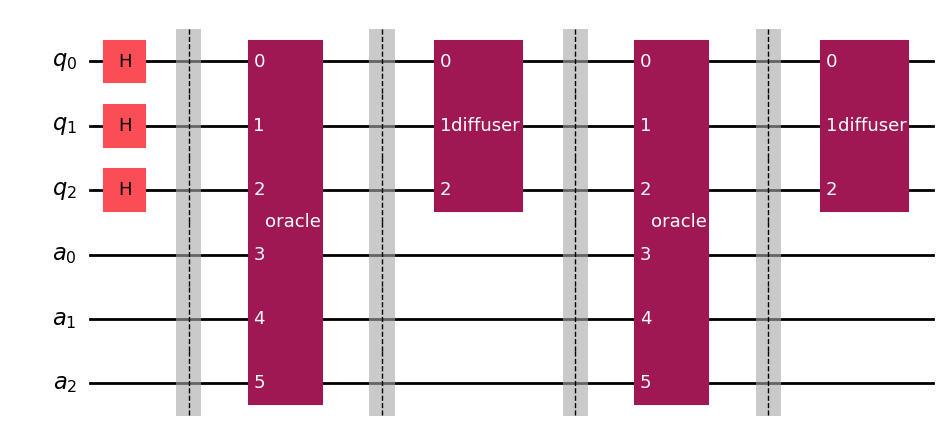

In [336]:
qc = eigenvalue_preparation(np.array([1, (1+1j)/np.sqrt(2),1j,(-1+1j)/np.sqrt(2), -1,-(1+1j)/np.sqrt(2), -1j, (1-1j)/np.sqrt(2)]), 3, 0.25)
display(qc.draw("mpl"))

## Testing probability of success

Now we run some tests to determine the accuracy of our algorithm. We run eigenvalue_preparation using $d=n$, and $U$ randomly chosen so that $\varphi(x)=t$ for a known $x$ and $t$. Note that the probability of `eigenvalue_preparation` failing is given by $\mathbb{P}(\text{failure})=1-|\langle x | \psi(n) \rangle|^2$, where $\psi(n)$ is the state vector of the circuit outputted by eigenvalue_preparation. We then plot values $(n, \log_2(\mathbb{P}(\text{failure}))$ in an attempt to verify that $\mathbb{P}(\text{failure}) = O \left( 2^{-n} \right)$, as with Grover search. 

First, we build some functions to help us build a random unitary of specified size with the correct properties to be used in `eigenvalue_preparation`, along with us specifying which state $|x \rangle$ the `eigenvalue_preparation` circuit should yield with high probability:

In [339]:
# Generates U with theta(desired_state)=target
def random_phase_unitary(
    dimension: int, precision: int, desired_state: int, target: float
):
    '''Generates a random diagonal Unitary of specified dimension with desired_state being basis vector with target phase.
    Entries are generated to be m'th roots of unity for m = 2^(precision)'''
    # Permututation of [0,...,2**d]\{target}, take first [2**n] to build unitary from
    v = np.random.permutation(
        np.delete(np.arange(2**precision), int(target * 2**precision))
    )[: (1 << dimension) - 1]
    # Impose theta(desired_state)= target_state
    v = np.insert(v, desired_state, int(target * 2**precision))
    # Exponentiate v to get unitary
    random_diag = np.exp(np.pi * v / (2 ** (precision - 1)) * 1j)
    return random_diag

In [ ]:
def eigenprep_probs(unitary, precision: int, target: float):
    '''Returns the probability distribution of the eigenvector preparation applied to given unitary operator
    with specified target phase.'''
    
    psi = Statevector(eigenvalue_preparation(unitary, precision, target))
    probs = np.array(psi.probabilities())[: len(unitary)]
    return probs

In [ ]:
def success_prob(dimension: int, precision: int, state: int, target: int):
    '''Generates random diagonal unitary with specified dimension, precision, target phase and state with said phase.
     Returns probability of success of the eigenvalue preparation algorithm, computed from the state vector of the circuit.'''
     
    unitary = random_phase_unitary(dimension, precision, state, target)
    return eigenprep_probs(unitary, precision, target)[state]

In [ ]:
state = 5
phase = 1 / 4  # state and phase

test_dim = np.arange(3, 7)
success_probs = np.float64(
    [
        success_prob(int(test_dim[i]), int(test_dim[i]), state, phase)
        for i in range(test_dim.size)
    ]
)
failure_probs = 1 - success_probs  # Plot failure probs

# Expect linear if P(failure) = O(2^{-n}): but can only simulate for small n!
failure_probs_log = np.log(failure_probs)
plt.xlabel('Number of qubits')
plt.ylabel(rf'$log_2(P( \text{{failure}}))$')
failure_plot = plt.plot(test_dim, failure_probs_log, "ro")


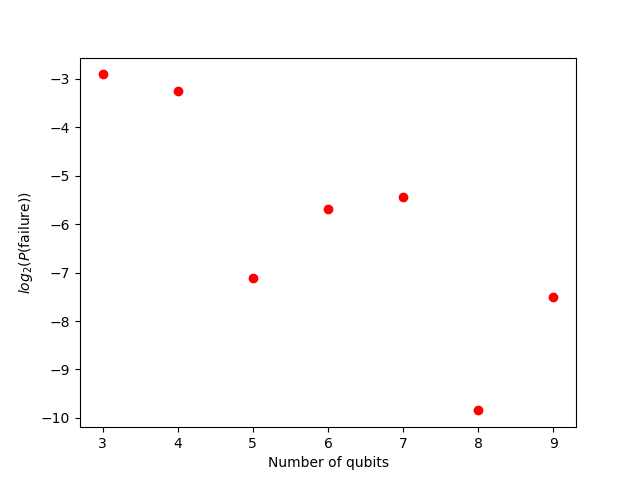

In [334]:
display(Image("./Figures/failure_prob_n3_to_n9.png"))

Note that $\mathbb{P}(\text{failure})$ is not monotone decreasing for small $n$ due to the floor function involved when calculating the optimal number of iterations, $K$, of Grover search! However, the impact is negligible once $K = O(\sqrt{2^n})$ becomes sufficiently large. 

We can also use AerSimulator to simulate the results of measuring our circuit:

In [ ]:
def eigenvalue_prep_counts(
    unitary, precision: int, target: float, shots=10000, iterations=None
):
    '''Returns counts for simulation of eigenvalue preparation circuit, measuring all non-ancilla bits at the end'''
    n = int(np.log2(len(unitary)))
    #Prepare circuit with classical bits in order to measure found state
    qc = QuantumCircuit(0, n)
    
    qc = eigenvalue_preparation(unitary, precision, target, iterations).compose(qc)
    
    #measure non-ancilla register into classical bits
    qc.measure(range(n), range(n))

    backend = AerSimulator(method="statevector")
    qc = transpile(qc, backend)

    job_statevector = backend.run(qc, shots=shots)
    counts_statevector = job_statevector.result().get_counts(0)
    return counts_statevector

Example histogram for $n=d$ for different values of $n$. We again observe the probability of success dipping for $n=6,7$.

In [ ]:
qubit_range = range(3,9)
desired_state = 5 
counts_list = []
legend = []
shots = 10000

for num_qubits in qubit_range:
    n = num_qubits
    d= num_qubits
     # binary: 110
    target = np.random.randint(2**d) / (2**d)  # arbitrary
    U = random_phase_unitary(n, d, desired_state, target)
    counts = eigenvalue_prep_counts(U,d,target,shots)
    trailing_string = '0'*(n-3) + '101'
    counts['101'] = counts.pop(trailing_string)
    counts_list.append(counts)
    legend.append(f"n={n}")

plot_histogram(counts_list, legend=legend, title="Outcome frequency",number_to_keep=1,figsize=(10,6))


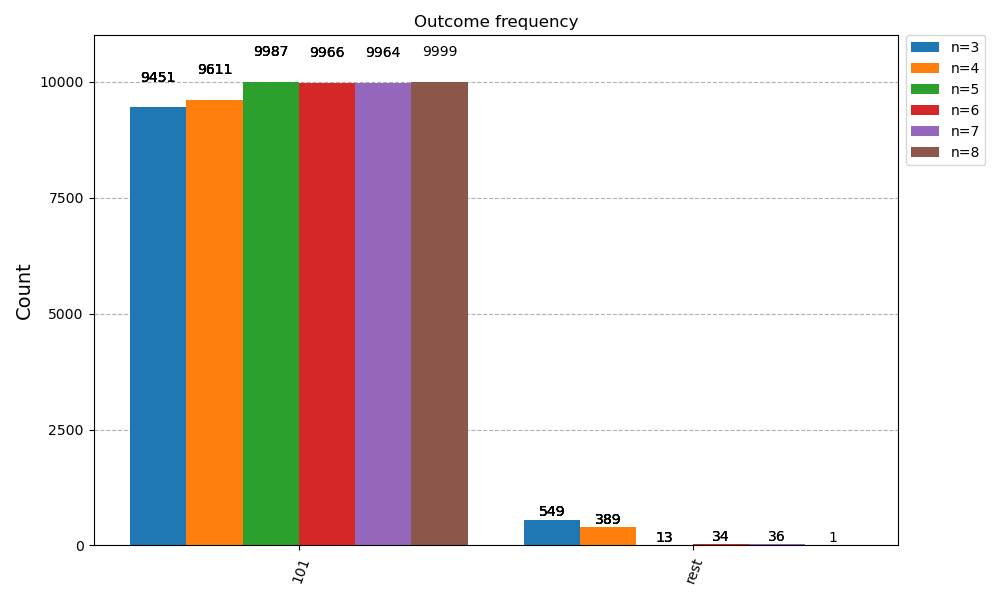

In [311]:
display(Image("./Figures/Eigenprep_Histogram.png"))